# 3.4 Third iteration: sentiment source and combination strategy

Recap. `3.0` found sentiment's raw correlation with `abnormal_return_1d` real but weak (0.033-0.046)
and ruled out magnitude as the fix, a louder article doesn't move the stock more. It named the likely
cause instead: one article's sentiment is scored against a whole day's return, but active days often
carry several articles, and nothing distinguishes "the one bearish article in a bullish day" from "one
of many."

`3.2` echoed this from the model's side. Feature importance on the first combined model put every one
of the top 10 features from the market side, sentiment's first appearance came 11th, and 59.9% of
total importance sat in the top 5. Loss-minimising boosting favours whichever feature cuts training
loss fastest, and sentiment's near-zero raw correlation gives a tree very little to split on next to
continuous, autocorrelated market features, so this isn't sentiment being tried and discarded, it's a
structural mismatch. `3.2` then found a second, bigger problem before trusting any of it: fold sizes
from `day_grouped_splits` were wildly uneven, and a classifier given only market features could
fingerprint which fold a row belonged to at 99.6% accuracy, an easy substitute for reading the article
at all. Order of work was set there: fix the harness before touching sentiment.

`3.3` fixed the harness (`row_grouped_splits` + `weighted_aggregate`, baseline accuracy 57.5%, AUC
0.570, two folds now significant) and then tested the fingerprint directly rather than assuming it
survived: drop the three features the fold-id classifier leaned on hardest
(`momentum_20d`/`momentum_1d`/`news_volume`), re-run, see what breaks. Partial confirmation, not
clean. Fold 4 collapsed below its own baseline, real dependence. Fold 1 barely moved, but only because
`volatility_20d`, `beta_20d`, and `days_to_earnings` substitute for the dropped three just as well,
several market features are redundant fingerprints for "which burst is this," not just the original
three. `3.3`'s handoff: distrust any gain that shows up mainly in folds 1 or 4.

This notebook is the sentiment half `3.2` deferred. Four configs, run independently, all against
`3.3`'s baseline, same harness (`evaluate_v2`, `row_grouped_splits`, `n_splits=5`):

1. **Relative sentiment** - subtract the day's mean sentiment from each article's score.
2. **Day-level aggregation** - collapse each day's articles into one row, predict the day's return.
3. **Market/text ensemble** - fit separately, blend predictions, vs. one combined model.
4. **Baseline** - `3.3`'s combined model, carried forward for the comparison table.

Each section states the change, the result against baseline, and whether any improvement holds up
under the same fingerprint check `3.3` used - especially for gains landing on folds 1 or 4. Closes with
one comparison table and a decision on what carries into iteration 4.

### 0. Setup

Imports and the same source table `3.2`/`3.3` used: `label_and_features_model_ready.parquet`,
sentiment and market features already joined to the 1-day label. Harness is `evaluate_v2`
(`row_grouped_splits`, `weighted_aggregate`), the one `3.3` fixed and settled on, `n_splits=5`
throughout, per its own finding that more folds only hurts on this corpus.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from news_sentiment.config import PROCESSED_DATA_DIR, REPORTS_DIR
from news_sentiment.market.evaluate_v2 import (
    row_grouped_splits,
    evaluate,
    weighted_aggregate,
    feature_importance,
)

pd.set_option("display.max_colwidth", 200)

df = pd.read_parquet(PROCESSED_DATA_DIR / "label_and_features_model_ready.parquet")
df = df.sort_values("timestamp_utc").reset_index(drop=True)

SESSION_CATEGORIES = ["pre-market", "market-hours", "after-hours"]
df["session"] = pd.Categorical(df["session"], categories=SESSION_CATEGORIES)

print("label_and_features_model_ready:", df.shape)
print("active days:", df["timestamp_utc"].dt.normalize().nunique())
df.head()

2026-08-27 12:13:40.439 | INFO     | news_sentiment.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


label_and_features_model_ready: (1976, 38)
active days: 92


,article_id,ticker,timestamp_utc,source,n_total_sents,n_entity_sents,n_ceo_sents,n_boilerplate_sents,entity_share,article_length,...,beta_20d,relative_volume_20d,daily_range_ratio_1d,days_to_earnings,session,news_volume,label_direction_3d,has_ceo_mention,fus_conf_graft_floor_mean_shrunk,fus_trusted_mean_shrunk
0,138796882,TSLA,2025-08-22 08:13:15+00:00,Benzinga,19,1,0,5,0.052632,2611,...,1.705859,0.709182,0.019431,61,pre-market,3,1,False,0.081243,0.081243
1,136476320,TSLA,2025-08-22 10:40:18+00:00,Yahoo,26,4,0,0,0.153846,3256,...,1.705859,0.709182,0.019431,61,pre-market,0,1,False,-0.017239,-0.017239
2,136476576,TSLA,2025-08-22 10:48:06+00:00,Yahoo,20,1,0,11,0.050000,3356,...,1.705859,0.709182,0.019431,61,pre-market,1,1,False,-0.140198,-0.140198
3,138802535,TSLA,2025-08-22 11:10:13+00:00,Benzinga,32,4,0,5,0.125000,4997,...,1.705859,0.709182,0.019431,61,market-hours,13,1,False,-0.168644,-0.168644
4,136476575,TSLA,2025-08-22 11:31:03+00:00,Yahoo,20,2,12,5,0.100000,3352,...,1.705859,0.709182,0.019431,61,pre-market,2,1,True,-0.246081,-0.246081


### 1. Features, label, and model factor

Same split into `TEXT_FEATURES`/`MARKET_FEATURES`, same label, same `model_factory`. Held fixed here
so every config in this notebook is compared on the same terms `3.3`'s baseline was; each config below
changes the feature values or the prediction unit going into these, never the model or its
hyperparameters.

In [2]:
TEXT_FEATURES = [
    "n_total_sents", "n_entity_sents", "n_ceo_sents", "n_boilerplate_sents",
    "entity_share", "article_length",
    "fus_conf_graft_floor_mean_shrunk", "fus_conf_graft_floor_median",
    "fus_conf_graft_floor_lead", "fus_conf_graft_floor_top3_pos",
    "fus_conf_graft_floor_top3_neg", "fus_conf_graft_floor_spread",
    "fus_ceo_mean", "has_ceo_mention", "fus_headline", "fus_maxmag",
    "fus_trusted_mean_shrunk", "fus_scorer_gap", "fus_headline_gap", "fus_lead_gap",
]

MARKET_FEATURES = [
    "momentum_1d", "momentum_5d", "momentum_20d", "volatility_20d", "beta_20d",
    "relative_volume_20d", "daily_range_ratio_1d", "days_to_earnings", "session", "news_volume",
]

MODEL_FEATURES = TEXT_FEATURES + MARKET_FEATURES
LABEL = "label_direction"

assert len(MODEL_FEATURES) == len(set(MODEL_FEATURES))
assert set(MODEL_FEATURES + [LABEL]).issubset(df.columns)


def model_factory():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=100,
        num_leaves=7,
        learning_rate=0.05,
        min_child_samples=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
    )


print(f"TEXT_FEATURES:   {len(TEXT_FEATURES)}")
print(f"MARKET_FEATURES: {len(MARKET_FEATURES)}")
print(f"MODEL_FEATURES:  {len(MODEL_FEATURES)}")
print(f"LABEL:           {LABEL!r}  {df[LABEL].value_counts().to_dict()}")

TEXT_FEATURES:   20
MARKET_FEATURES: 10
MODEL_FEATURES:  30
LABEL:           'label_direction'  {1: 996, -1: 980}


### 2. Baseline: `3.3`, restated

Recomputed here, not copied as numbers, so it's a live `EvalResult` every config below is scored
against.

In [3]:
baseline_combined = evaluate(model_factory, df, MODEL_FEATURES, label_col=LABEL)
baseline_market = evaluate(model_factory, df, MARKET_FEATURES, label_col=LABEL)
baseline_text = evaluate(model_factory, df, TEXT_FEATURES, label_col=LABEL)

agg = pd.DataFrame({
    "market_only": baseline_market.aggregate.loc["mean"],
    "text_only": baseline_text.aggregate.loc["mean"],
    "combined": baseline_combined.aggregate.loc["mean"],
    "combined_weighted": weighted_aggregate(baseline_combined).loc["weighted_mean_by_n_test"],
}).round(4)
print(agg.loc[["accuracy", "auc", "log_loss", "brier_score", "majority_baseline_accuracy", "mcnemar_p_value"]].to_string())

                            market_only  text_only  combined  combined_weighted
accuracy                         0.5674     0.5181    0.5751             0.5757
auc                              0.5057     0.5220    0.5695             0.5710
log_loss                         0.9205     0.7420    0.8747             0.8741
brier_score                      0.2958     0.2701    0.2851             0.2847
majority_baseline_accuracy       0.4812     0.4812    0.4812             0.4811
mcnemar_p_value                  0.3260     0.2913    0.2502             0.2495


### 3. Config 1: relative sentiment

Subtract each day's mean sentiment from every article's own score, so the model reads "more positive
than the day's tone" instead of a raw score competing with everything else published that day. `3.0`
section 12 and `3.2` section 6.3 both named this; built here for the first time.

#### 3.1 Which features generalize to a relative transform?

Section 3's opening only touched `fus_conf_graft_floor_mean_shrunk`. `TEXT_FEATURES` carries 19 other
columns; worth asking which of them the same "subtract the day's mean" idea actually applies to before
building just the one. Three groups, by what kind of column each is:

- **Structural/count** - `n_total_sents`, `n_entity_sents`, `n_ceo_sents`, `n_boilerplate_sents`,
  `entity_share`, `article_length`, `has_ceo_mention`. Not sentiment scores at all, out of scope here.
- **Already a difference** - `fus_conf_graft_floor_spread`, `fus_scorer_gap`, `fus_headline_gap`,
  `fus_lead_gap`. Each already measures one thing relative to another (top3 spread, scorer
  disagreement, headline vs. body). Subtracting a *third* thing, the day's mean, on top is a
  compound transform this notebook isn't building yet; left as an open question, not ruled out.
- **Per-article sentiment scores** - `fus_conf_graft_floor_median`, `fus_conf_graft_floor_lead`,
  `fus_conf_graft_floor_top3_pos`, `fus_conf_graft_floor_top3_neg`, `fus_ceo_mean`, `fus_headline`,
  `fus_maxmag`, `fus_trusted_mean_shrunk`, alongside the mean already done. These are the real
  candidates, structurally the same kind of column the mean is.

One thing worth being explicit about: `3.0` ruled `fus_maxmag` and `fus_headline` out of the
*shrinkage* fix, on the grounds that a single sentence or a single string can't be shrunk by
population size, there's no population. That reasoning doesn't carry over here. Relative-to-day
doesn't ask "how much evidence backs this score," it asks "how does this score compare to what else
published that day," a question a single sentence's score can answer just as well as a twenty-sentence
mean can. Shrinkage-ineligible isn't the same as relative-ineligible; re-derived from scratch rather
than inherited.

In [4]:
STRUCTURAL_COLS = [
    "n_total_sents", "n_entity_sents", "n_ceo_sents", "n_boilerplate_sents",
    "entity_share", "article_length", "has_ceo_mention",
]
ALREADY_DIFFERENCE_COLS = [
    "fus_conf_graft_floor_spread", "fus_scorer_gap", "fus_headline_gap", "fus_lead_gap",
]
RELATIVE_CANDIDATES = [
    c for c in TEXT_FEATURES if c not in STRUCTURAL_COLS + ALREADY_DIFFERENCE_COLS
]

assert set(STRUCTURAL_COLS + ALREADY_DIFFERENCE_COLS + RELATIVE_CANDIDATES) == set(TEXT_FEATURES)
print(f"structural/count, out of scope:    {len(STRUCTURAL_COLS)}")
print(f"already a difference, deferred:    {len(ALREADY_DIFFERENCE_COLS)}")
print(f"relative-transform candidates:     {len(RELATIVE_CANDIDATES)}")
print(RELATIVE_CANDIDATES)

structural/count, out of scope:    7
already a difference, deferred:    4
relative-transform candidates:     9
['fus_conf_graft_floor_mean_shrunk', 'fus_conf_graft_floor_median', 'fus_conf_graft_floor_lead', 'fus_conf_graft_floor_top3_pos', 'fus_conf_graft_floor_top3_neg', 'fus_ceo_mean', 'fus_headline', 'fus_maxmag', 'fus_trusted_mean_shrunk']


#### 3.2 Building the features

All 9 candidates from 3.1, not just the mean. Same transform each time, day mean subtracted from the
row's own value, `fus_conf_graft_floor_mean_shrunk` keeps the name `fus_relative_sentiment` it already
has downstream in section 3.3; the rest get `fus_relative_<name>`. The solo-article-day edge case from
3.2's first pass is structural to the grouping, not the column, so it's checked once, across all 9,
rather than repeated per feature.

In [5]:
day = df["timestamp_utc"].dt.normalize()
articles_per_day = df.groupby(day)["article_id"].transform("count")
solo_day = articles_per_day == 1

RELATIVE_COLUMN_MAP = {
    "fus_conf_graft_floor_mean_shrunk": "fus_relative_sentiment",
    "fus_conf_graft_floor_median": "fus_relative_median",
    "fus_conf_graft_floor_lead": "fus_relative_lead",
    "fus_conf_graft_floor_top3_pos": "fus_relative_top3_pos",
    "fus_conf_graft_floor_top3_neg": "fus_relative_top3_neg",
    "fus_ceo_mean": "fus_relative_ceo_mean",
    "fus_headline": "fus_relative_headline",
    "fus_maxmag": "fus_relative_maxmag",
    "fus_trusted_mean_shrunk": "fus_relative_trusted_mean",
}
assert set(RELATIVE_COLUMN_MAP) == set(RELATIVE_CANDIDATES)

for raw_col, rel_col in RELATIVE_COLUMN_MAP.items():
    day_mean = df.groupby(day)[raw_col].transform("mean")
    df[rel_col] = df[raw_col] - day_mean

print(f"solo-article days: {solo_day.sum()} rows ({solo_day.mean():.1%} of corpus)")
print()
print("solo-day rows land on 0 (or NaN, for columns already NaN that day):")
for raw_col, rel_col in RELATIVE_COLUMN_MAP.items():
    solo_vals = df.loc[solo_day, rel_col]
    ok = ((solo_vals == 0.0) | solo_vals.isna()).all()
    print(f"  {rel_col:28s} {ok}")

solo-article days: 2 rows (0.1% of corpus)

solo-day rows land on 0 (or NaN, for columns already NaN that day):
  fus_relative_sentiment       True
  fus_relative_median          True
  fus_relative_lead            True
  fus_relative_top3_pos        True
  fus_relative_top3_neg        True
  fus_relative_ceo_mean        True
  fus_relative_headline        True
  fus_relative_maxmag          True
  fus_relative_trusted_mean    True


How the transform changed each column: standard deviation (within-day variance removed shrinks
it, unless within-day variance was most of the variance to begin with, in which case it barely
moves), and whether the transform preserves or breaks each column's original zero/NaN structure.
`fus_relative_lead` and `fus_relative_ceo_mean` are the ones to watch, both raw columns are
structurally 0 or NaN on a large share of rows (`3.0` sections 3, 10.1), and the transform must not
manufacture a nonzero value out of a row that had no signal to begin with.

In [6]:
summary_rows = []
for raw_col, rel_col in RELATIVE_COLUMN_MAP.items():
    summary_rows.append({
        "feature": raw_col,
        "raw_std": df[raw_col].std(),
        "relative_std": df[rel_col].std(),
        "std_ratio": df[rel_col].std() / df[raw_col].std(),
        "raw_zero_or_na": ((df[raw_col] == 0.0) | df[raw_col].isna()).mean(),
        "relative_zero_or_na": ((df[rel_col] == 0.0) | df[rel_col].isna()).mean(),
    })
summary = pd.DataFrame(summary_rows).round(4)
print(summary.to_string(index=False))

                         feature  raw_std  relative_std  std_ratio  raw_zero_or_na  relative_zero_or_na
fus_conf_graft_floor_mean_shrunk   0.1486        0.1409     0.9482          0.0157               0.0010
     fus_conf_graft_floor_median   0.3855        0.3686     0.9563          0.0157               0.0010
       fus_conf_graft_floor_lead   0.3592        0.3441     0.9581          0.3284               0.0025
   fus_conf_graft_floor_top3_pos   0.4359        0.4216     0.9672          0.0157               0.0010
   fus_conf_graft_floor_top3_neg   0.4611        0.4417     0.9579          0.0157               0.0010
                    fus_ceo_mean   0.3468        0.3224     0.9297          0.5207               0.5076
                    fus_headline   0.4310        0.4155     0.9641          0.0000               0.0010
                      fus_maxmag   0.6924        0.6642     0.9593          0.0157               0.0010
         fus_trusted_mean_shrunk   0.1487        0.1411     0.94

Standard deviation shrinks 3-7% across the board, modest, most of each score's variance is
between articles, not within a day, consistent with sentiment being a weak signal overall rather than
one dominated by day-to-day swings. The zero/NaN-structure check is the more important read.
`fus_ceo_mean` holds up: 52.1% raw NaN to 50.8% relative, close, because `groupby().transform("mean")`
skips `NaN` when computing the day mean, so a `NaN` row stays `NaN` after subtraction, structural
absence survives the transform intact.

`fus_conf_graft_floor_lead` doesn't. Structural zero drops from 32.8% to 0.25%, far more than the
~1.6% to ~0.1% every other candidate shows. The mechanism: `_lead` codes "no opening-window target
sentence" as `0.0`, not `NaN` (`3.0` section 10.1's convention), so those rows are *not* excluded from
the day mean the way `fus_ceo_mean`'s `NaN` rows are, and `0 - (nonzero day mean)` is essentially never
exactly 0 again. This isn't unique to `_lead`, the same thing happens to every 0-coded row in every
candidate here, it's just large enough to see because `_lead` is 0 on a third of the corpus rather than
1.6% of it. Not fixed here, `fus_relative_lead` goes into 3.3 as-is, but it's the column to watch if
the model result looks off: it has structurally recoded "no evidence" as "however far below the day's
tone," which isn't obviously the right reading of a structural absence.

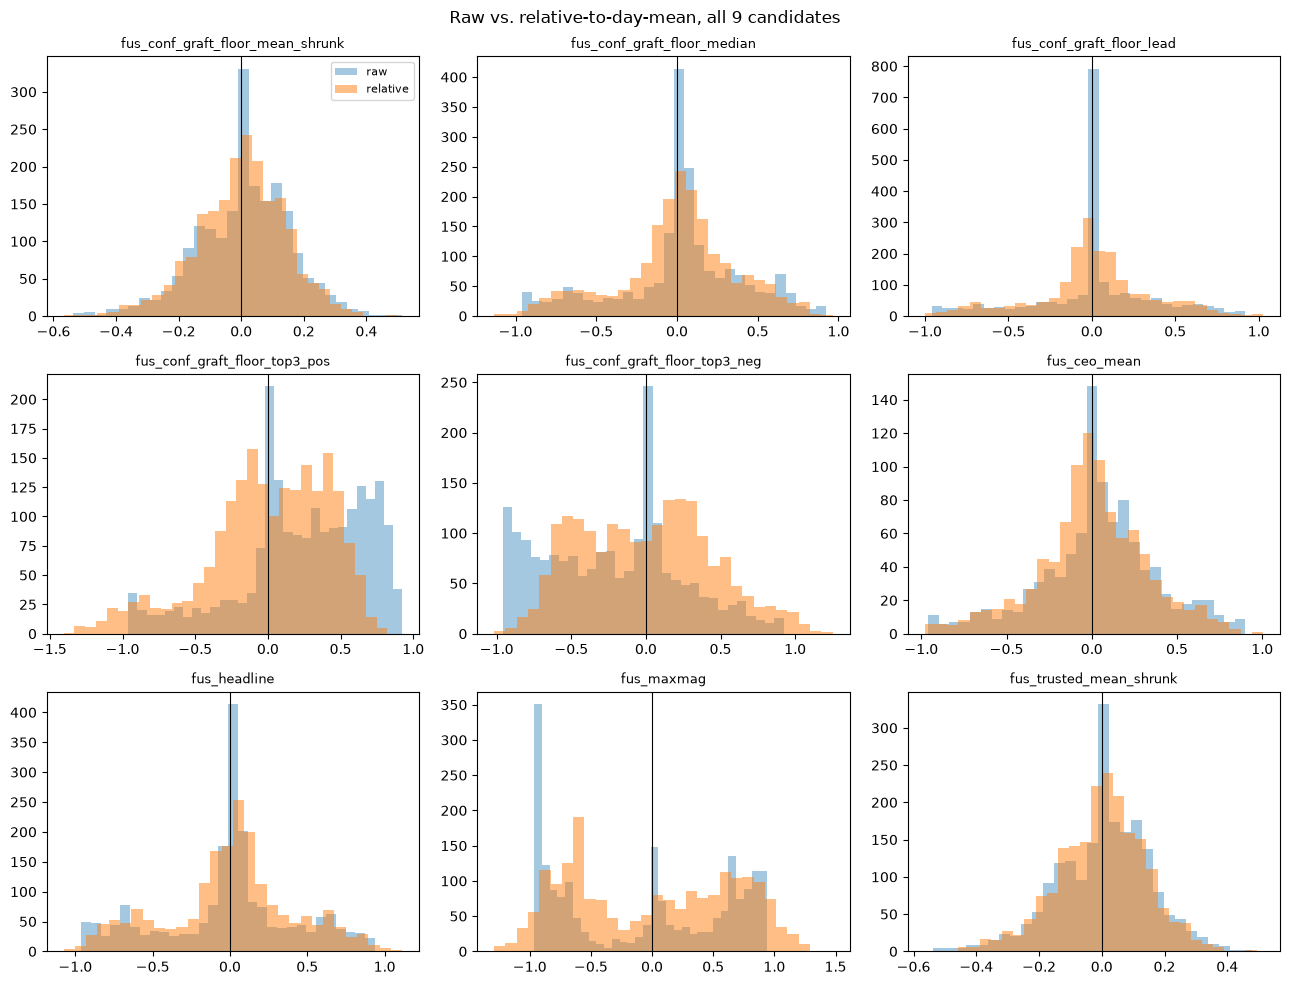

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, (raw_col, rel_col) in zip(axes.flat, RELATIVE_COLUMN_MAP.items()):
    ax.hist(df[raw_col].dropna(), bins=30, alpha=0.4, label="raw", color="tab:blue")
    ax.hist(df[rel_col].dropna(), bins=30, alpha=0.5, label="relative", color="tab:orange")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(raw_col, fontsize=9)
axes.flat[0].legend(fontsize=8)
fig.suptitle("Raw vs. relative-to-day-mean, all 9 candidates")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "3.4-relative-candidates-distributions.png", dpi=150)
plt.show()

The grid reads as one story repeated eight times, plus one exception. For every candidate except
`fus_relative_lead`, raw and relative overlap almost on top of each other, same shape, same skew,
slightly narrower peak, exactly what a few-percent standard-deviation drop (summary table above) should
look like: the day-mean subtraction is a small correction, not a reshaping. `fus_relative_lead` is
visibly different, its zero spike is gone, smeared into the surrounding bins, the direct picture of the
32.8%-to-0.25% structural-zero collapse already flagged above.

#### 3.3 Running through the harness

`TEXT_FEATURES_RELATIVE` swaps all 9 candidates for their relative versions via `RELATIVE_COLUMN_MAP`,
everything else in section 1's lists unchanged. Combined and text-only, both against `3.3`'s baseline
from section 2, same model, same harness, same folds.

In [8]:
TEXT_FEATURES_RELATIVE = [RELATIVE_COLUMN_MAP.get(c, c) for c in TEXT_FEATURES]
MODEL_FEATURES_RELATIVE = TEXT_FEATURES_RELATIVE + MARKET_FEATURES
assert len(TEXT_FEATURES_RELATIVE) == len(TEXT_FEATURES)

relative_combined = evaluate(model_factory, df, MODEL_FEATURES_RELATIVE, label_col=LABEL)
relative_text = evaluate(model_factory, df, TEXT_FEATURES_RELATIVE, label_col=LABEL)

per_fold = pd.DataFrame({
    "baseline_acc": baseline_combined.metrics_df["accuracy"],
    "relative_acc": relative_combined.metrics_df["accuracy"],
    "baseline_auc": baseline_combined.metrics_df["auc"],
    "relative_auc": relative_combined.metrics_df["auc"],
    "n_test": baseline_combined.metrics_df["n_test"],
}).round(4)
per_fold.index = per_fold.index + 1
print("combined, baseline vs. all-relative, per fold:")
print(per_fold.to_string())
print()

compare = pd.DataFrame({
    "baseline_combined": baseline_combined.aggregate.loc["mean"],
    "relative_combined": relative_combined.aggregate.loc["mean"],
    "baseline_text": baseline_text.aggregate.loc["mean"],
    "relative_text": relative_text.aggregate.loc["mean"],
}).round(4)
print("mean across folds:")
print(compare.loc[["accuracy", "auc", "log_loss", "brier_score", "majority_baseline_accuracy", "mcnemar_p_value"]].to_string())

combined, baseline vs. all-relative, per fold:
   baseline_acc  relative_acc  baseline_auc  relative_auc  n_test
1        0.7287        0.7287        0.7008        0.6886     328
2        0.4238        0.4146        0.4817        0.4652     328
3        0.4281        0.4159        0.4304        0.4111     327
4        0.7134        0.7164        0.7697        0.7816     335
5        0.5812        0.5875        0.4649        0.5125     320

mean across folds:
                            baseline_combined  relative_combined  baseline_text  relative_text
accuracy                               0.5751             0.5726         0.5181         0.5384
auc                                    0.5695             0.5718         0.5220         0.5635
log_loss                               0.8747             0.8754         0.7420         0.7263
brier_score                            0.2851             0.2852         0.2701         0.2631
majority_baseline_accuracy             0.4812             0.48

Flat on the combined model, decisive on text-only. Combined mean accuracy is essentially
unchanged, 57.5% to 57.3%, AUC ticks up slightly, 0.570 to 0.572. Per fold, fold 1 doesn't move at all
(72.9% both ways) and fold 4 barely does (71.3% to 71.6%), neither showing the kind of jump `3.3`
traced to regime-fingerprinting, so this combined-model result reads as genuinely flat rather than
flattered by regime-matching.

Text-only is the real result here: accuracy 51.8% to 53.8%, AUC 0.522 to 0.564, log loss 0.742 to
0.726, Brier 0.270 to 0.263, `mcnemar_p_value` 0.291 to 0.110, the closest to significance anything in
this notebook has come.

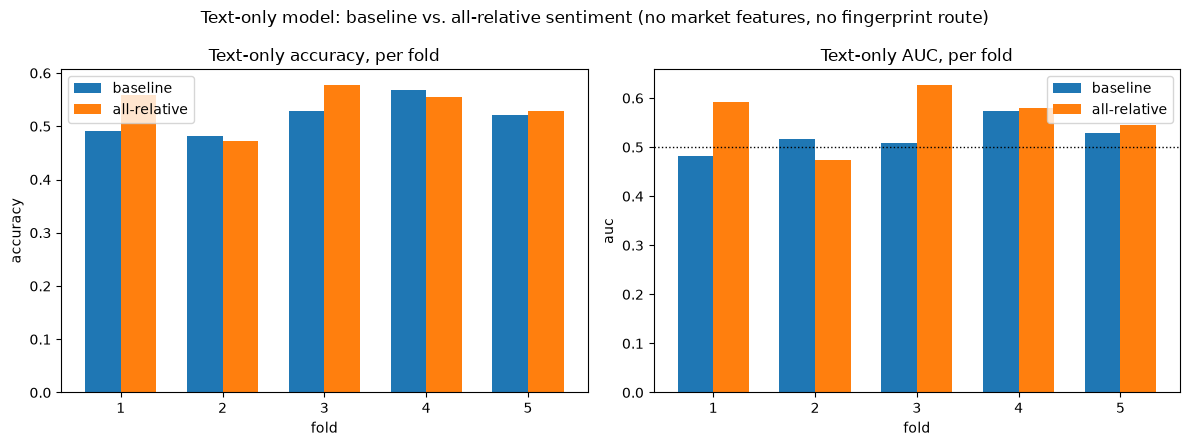

In [9]:
text_per_fold = pd.DataFrame({
    "baseline_acc": baseline_text.metrics_df["accuracy"],
    "relative_acc": relative_text.metrics_df["accuracy"],
    "baseline_auc": baseline_text.metrics_df["auc"],
    "relative_auc": relative_text.metrics_df["auc"],
}).round(4)
text_per_fold.index = text_per_fold.index + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(1, 6)
w = 0.35

axes[0].bar(x - w / 2, text_per_fold["baseline_acc"], width=w, label="baseline")
axes[0].bar(x + w / 2, text_per_fold["relative_acc"], width=w, label="all-relative")
axes[0].set_xticks(x)
axes[0].set_xlabel("fold")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Text-only accuracy, per fold")
axes[0].legend()

axes[1].bar(x - w / 2, text_per_fold["baseline_auc"], width=w, label="baseline")
axes[1].bar(x + w / 2, text_per_fold["relative_auc"], width=w, label="all-relative")
axes[1].axhline(0.5, color="black", linestyle=":", linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xlabel("fold")
axes[1].set_ylabel("auc")
axes[1].set_title("Text-only AUC, per fold")
axes[1].legend()

fig.suptitle("Text-only model: baseline vs. all-relative sentiment (no market features, no fingerprint route)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "3.4-relative-text-only-per-fold.png", dpi=150)
plt.show()

No single fold is carrying this the way fold 4 carried the combined model's apparent gain
earlier in this project. Accuracy improves in 3 of 5 folds and AUC in 4 of 5, spread rather than
concentrated, and there's no fingerprint mechanism available here to begin with, `TEXT_FEATURES_RELATIVE`
has no market columns in it at all.

**Reading the two results together:** the day-relative transform's value is in the text signal itself,
not in how it interacts with market features. On the combined model it's flat, no fingerprint to hide
behind and no real lift either. On text-only, where fingerprinting has no route to explain anything, it
moves every metric the right way.

#### 3.4 Feature importance: does sentiment carry more weight now?

Everything above answers "did the score improve." It doesn't answer the question this whole config was
built for: whether the combined model actually leans on sentiment more once it's relative, or whether
`3.2`'s finding still holds, every one of the top 10 features market, sentiment's first appearance 11th,
top 5 covering 59.9% of total importance. Same `feature_importance()` call `3.2` used, run on
`relative_combined` and `MODEL_FEATURES_RELATIVE` instead.

In [10]:
fi_relative = feature_importance(relative_combined, MODEL_FEATURES_RELATIVE)
fi_relative["is_text"] = fi_relative["feature"].isin(TEXT_FEATURES_RELATIVE)

print(fi_relative.to_string(index=False))
print()
top10 = fi_relative.head(10)
print("text features in the top 10:", top10.loc[top10["is_text"], "feature"].tolist())
print("top 5 share of total mean importance:",
      (fi_relative["importance_mean"].head(5).sum() / fi_relative["importance_mean"].sum()).round(4))

first_text_rank = fi_relative.reset_index(drop=True).loc[fi_relative.reset_index(drop=True)["is_text"]].index.min() + 1
print(f"first text feature ranks: {first_text_rank}  (3.2's original combined model: 11th)")

                    feature  importance_mean  importance_std  is_text
                news_volume            120.8       23.944937    False
           days_to_earnings             82.6        9.830565    False
             volatility_20d             60.0       10.899541    False
        relative_volume_20d             50.4       13.690873    False
                   beta_20d             41.0       11.781341    False
               momentum_20d             40.4       13.350655    False
                momentum_1d             35.8       15.144636    False
                    session             31.8        8.634813    False
       daily_range_ratio_1d             30.6       14.540977    False
                momentum_5d             24.0       11.401754    False
        fus_relative_maxmag             11.2        3.969887     True
             fus_scorer_gap              9.0        4.690416     True
             article_length              6.2        5.979967     True
        n_boilerplat

No. The answer this config was actually built to answer is no: the model still doesn't lean on
sentiment more. The top 10 is every market feature again, same as `3.2`, and the first text feature
still ranks 11th, this time `fus_relative_maxmag` at 11.2 rather than `fus_scorer_gap`, but the same
position exactly. Top 5 share of total importance: 59.8%, against `3.2`'s 59.9%, a difference too small
to be anything but noise.

That's consistent with, not contradicted by, section 3.3's text-only result. `evaluate()`'s combined
model still finds market features easier to split on for the reasons `3.2` gave, more continuous split
points, genuinely autocorrelated, loss-minimising boosting reaches for them structurally regardless of
how good the sentiment features are on their own. The relative transform improved what sentiment can do
*in isolation*; it did nothing to change *which features a tree fitted on both groups together prefers*.
Those are different questions, and this config only answers the second one no. Also worth noting which
text feature now leads: `fus_relative_maxmag`, not `fus_relative_sentiment`, the single loudest sentence
relative to its day, edges out the primary mean once every candidate is available to compete for splits.

### 4. Config 2: market-session aggregation

Config 1 asked whether an article's sentiment reads better measured against the day's tone. This one
asks the more structural version of the same problem, named alongside it in `3.0` section 12 and `3.2`
section 6.3: `abnormal_return_1d` is one number for a whole trading session, but a session routinely
carries several articles, so one row per article asks each article to individually explain a move that
everything else published ahead of that session also contributed to. Collapsing the prediction unit
from article to session removes that mismatch directly, rather than reweighting each article's score
against it the way config 1 did.

The grouping unit is the target market session, not the calendar day. `abnormal_return_1d` already
carries this: a pre-market article's 1-day return points to that session's own next market-hours close,
while a market-hours or after-hours article's return points to the *next* market-hours session, which
can land on a later calendar date, past a weekend included. Grouping by calendar date would silently mix
two different target sessions together; grouping by the return value itself doesn't, since two articles
only ever share a value when they're genuinely predicting the same session.

The change: each target session becomes one row, mean sentiment, article count, spread of opinion, and
the market state going into that session, aggregated from the current article-level table. That's a
bigger structural change than config 1's, a different label distribution, an order of magnitude fewer
rows (roughly 70 sessions against 1,976 articles), and a metric this notebook hasn't had to weigh yet,
how much evidence a table this size can actually support. Built and checked before any model runs on
it, same order this notebook has followed throughout.

#### 4.1 Building the session-level table

Grouped by `abnormal_return_1d`, the target return itself, one row per distinct value. Text features
aggregate across every article in the group, sum for volume counts, mean for scores, a signed max-abs
for `fus_maxmag`, std for sentiment spread. Market features are different in kind: `momentum_1d` and the
rest are anchored to each article's own *publish* time, not the target session, so they legitimately
vary across a group, an article published Friday afternoon and one published Monday pre-market see
different market states, correctly. The representative value per group is the *latest*-published
article's snapshot, the freshest read of market state going into the session. `session` becomes three
fraction columns describing the group's coverage timing (how much of it was pre-market vs. market-hours
vs. after-hours), not a grouping key. `n_splits` stays 5, per-fold row counts get revisited once results
exist.

In [11]:
target_mismatch = df.groupby("abnormal_return_1d")["label_direction"].nunique()
assert (target_mismatch == 1).all(), "abnormal_return_1d doesn't fully determine label_direction"

span = df.groupby("abnormal_return_1d")["timestamp_utc"].agg(lambda s: s.max() - s.min())
print(f"target-return groups: {df['abnormal_return_1d'].nunique()}  (vs. 92 calendar days)")
print(f"widest group's publish-time span: {span.max()}")
print(f"groups spanning more than 4 days: {(span > pd.Timedelta(days=4)).sum()}")

latest_idx = df.groupby("abnormal_return_1d")["timestamp_utc"].idxmax()
MARKET_SNAPSHOT_COLS = [
    "momentum_1d", "momentum_5d", "momentum_20d", "volatility_20d", "beta_20d",
    "relative_volume_20d", "daily_range_ratio_1d", "days_to_earnings", "news_volume",
]
latest_snapshot = (
    df.loc[latest_idx, ["abnormal_return_1d", "timestamp_utc"] + MARKET_SNAPSHOT_COLS]
    .set_index("abnormal_return_1d")
)


def signed_max_abs(s):
    return s.iloc[s.abs().values.argmax()]


day_df = df.groupby("abnormal_return_1d").agg(
    label_direction=("label_direction", "first"),
    n_total_sents=("n_total_sents", "sum"),
    n_entity_sents=("n_entity_sents", "sum"),
    n_ceo_sents=("n_ceo_sents", "sum"),
    n_boilerplate_sents=("n_boilerplate_sents", "sum"),
    article_length=("article_length", "sum"),
    fus_headline=("fus_headline", "mean"),
    fus_scorer_gap=("fus_scorer_gap", "mean"),
    fus_headline_gap=("fus_headline_gap", "mean"),
    fus_lead_gap=("fus_lead_gap", "mean"),
    fus_trusted_mean_shrunk=("fus_trusted_mean_shrunk", "mean"),
    has_ceo_mention=("has_ceo_mention", "mean"),
    entity_share=("entity_share", "mean"),
    fus_sentiment_mean=("fus_conf_graft_floor_mean_shrunk", "mean"),
    fus_sentiment_std=("fus_conf_graft_floor_mean_shrunk", "std"),
    fus_maxmag_day=("fus_maxmag", signed_max_abs),
    n_articles=("article_id", "count"),
    n_sources=("source", "nunique"),
)
day_df = day_df.join(latest_snapshot)

session_frac = (
    df.groupby("abnormal_return_1d")["session"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .reindex(columns=SESSION_CATEGORIES, fill_value=0.0)
    .add_suffix("_share")
)
day_df = day_df.join(session_frac)
day_df = day_df.reset_index().rename(columns={"abnormal_return_1d": "abnormal_return_1d"})
# sorted by timestamp_utc to match the row order evaluate() sorts to internally, so any
# manual indexing by a fold's train_idx/test_idx outside evaluate() (5.1/5.2) stays aligned
day_df = day_df.sort_values("timestamp_utc").reset_index(drop=True)

solo_article_group = day_df["n_articles"] == 1
print()
print(f"solo-article groups: {solo_article_group.sum()} ({solo_article_group.mean():.1%} of {len(day_df)})")
std_ok = (
    day_df.loc[solo_article_group, "fus_sentiment_std"].isna().all()
    and day_df.loc[~solo_article_group, "fus_sentiment_std"].notna().all()
)
print(f"fus_sentiment_std NaN on solo-article groups only: {std_ok}")
day_df["fus_sentiment_std"] = day_df["fus_sentiment_std"].fillna(0.0)

print()
print(f"day_df shape: {day_df.shape}")
print(f"any remaining NaN: {day_df.isna().sum().sum()}")
day_df.head()

target-return groups: 71  (vs. 92 calendar days)
widest group's publish-time span: 3 days 03:34:42
groups spanning more than 4 days: 0

solo-article groups: 2 (2.8% of 71)
fus_sentiment_std NaN on solo-article groups only: True

day_df shape: (71, 32)
any remaining NaN: 0


,abnormal_return_1d,label_direction,n_total_sents,n_entity_sents,n_ceo_sents,n_boilerplate_sents,article_length,fus_headline,fus_scorer_gap,fus_headline_gap,...,momentum_20d,volatility_20d,beta_20d,relative_volume_20d,daily_range_ratio_1d,days_to_earnings,news_volume,pre-market_share,market-hours_share,after-hours_share
0,0.046809,1,192,29,18,45,28369,-0.011237,0.519699,0.058275,...,0.048510,0.019837,1.705859,0.709182,0.019431,61,6,1.000000,0.000000,0.000000
1,0.023783,1,1261,286,42,214,175206,0.029443,0.452767,0.016306,...,0.075777,0.023487,2.205253,1.196079,0.060469,58,47,0.195652,0.326087,0.478261
2,0.010441,1,407,71,24,56,50722,0.075186,0.473289,0.072051,...,0.064529,0.023452,2.050682,1.102619,0.041835,57,40,0.437500,0.250000,0.312500
3,-0.008165,-1,702,116,13,57,102885,-0.030924,0.376703,-0.032515,...,0.094863,0.023407,2.045713,0.982679,0.023260,56,58,0.571429,0.333333,0.095238
4,-0.013896,-1,332,96,7,53,43265,-0.107933,0.331228,-0.002573,...,0.095787,0.021622,1.895756,0.850160,0.017820,55,58,0.866667,0.133333,0.000000


#### 4.2 Sanity pass

Same standard `3.0` opened with on the article-level table: label balance, distribution shape, and
whether anything here is degenerate, before any model touches it.

In [12]:
print("label_direction balance:")
print(day_df["label_direction"].value_counts())
print((day_df["label_direction"].value_counts(normalize=True) * 100).round(1).to_dict())
print()

print("session-share columns sum to 1 per row:",
      np.allclose(day_df[[c + "_share" for c in SESSION_CATEGORIES]].sum(axis=1), 1.0))
print()

print("n_articles per session:")
print(day_df["n_articles"].describe().round(2))
print()

print(day_df[["fus_sentiment_mean", "fus_sentiment_std", "abnormal_return_1d"]].describe().round(4))

label_direction balance:
label_direction
 1    38
-1    33
Name: count, dtype: int64
{1: 53.5, -1: 46.5}

session-share columns sum to 1 per row: True

n_articles per session:
count    71.00
mean     27.83
std      13.59
min       1.00
25%      19.00
50%      28.00
75%      38.50
max      58.00
Name: n_articles, dtype: float64

       fus_sentiment_mean  fus_sentiment_std  abnormal_return_1d
count             71.0000            71.0000             71.0000
mean               0.0057             0.1383              0.0033
std                0.0600             0.0401              0.0222
min               -0.1772             0.0000             -0.0484
25%               -0.0330             0.1178             -0.0103
50%                0.0068             0.1395              0.0014
75%                0.0434             0.1549              0.0170
max                0.2115             0.2367              0.0681


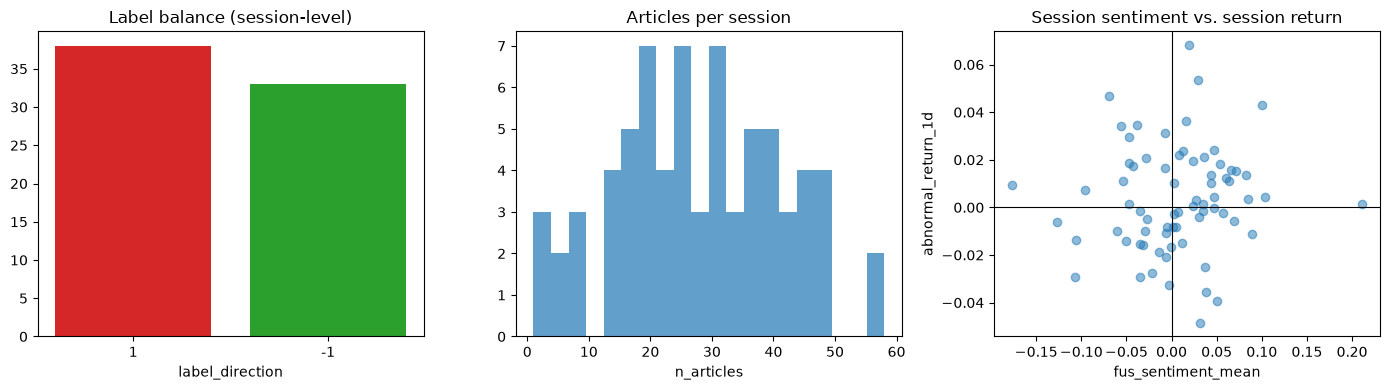

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(day_df["label_direction"].value_counts().index.astype(str),
            day_df["label_direction"].value_counts().values, color=["tab:red", "tab:green"])
axes[0].set_title("Label balance (session-level)")
axes[0].set_xlabel("label_direction")

axes[1].hist(day_df["n_articles"], bins=20, color="tab:blue", alpha=0.7)
axes[1].set_title("Articles per session")
axes[1].set_xlabel("n_articles")

axes[2].scatter(day_df["fus_sentiment_mean"], day_df["abnormal_return_1d"], alpha=0.5)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Session sentiment vs. session return")
axes[2].set_xlabel("fus_sentiment_mean")
axes[2].set_ylabel("abnormal_return_1d")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "3.4-session-level-sanity.png", dpi=150)
plt.show()

Nothing degenerate. Label balance is 53.5%/46.5%, close to the article-level table's 50.4%/49.6%,
session-share columns sum to exactly 1 on every row, and `n_articles` ranges 1 to 58 (mean 27.8, std
13.6), the same burstiness `3.0`/`3.2` found at the article level showing up again here, some sessions
are backed by a handful of articles, others by dozens.

The scatter is worth a number, not just a look: `corr(fus_sentiment_mean, abnormal_return_1d) = 0.071`
and directional accuracy 60.6%, both well above the article-level raw checks (`3.0`: 0.033-0.046 corr,
53.2% accuracy). That's the more interesting reading this table has produced yet, more than a passing
curiosity given the article-competing-for-attention mechanism this config exists to fix, but 71 rows is
a small enough sample that a raw correlation this size can still be noise, and `3.0`'s raw-check numbers
already contradicted a config's eventual harness result once this notebook (config 1's mean-only pass).
Not a verdict, a reason to actually run this through `evaluate()` rather than a reason to trust it yet.

#### 4.3 Running through the harness

Cannot reuse `model_factory` unchanged here. A first pass with it produced identical results across
market-only, text-only, and combined, every fold's AUC exactly 0.5 and accuracy exactly matching the
majority baseline. Checked directly: every fold's fitted model was a single-node stump, zero splits,
`min_child_samples=30` requires 30 rows per leaf, and this table's folds train on 13 to 61 rows total,
not enough for even one split on the smallest folds. Not a finding about the data, a hyperparameter
sized for article-level fold counts (250-1,600+ rows) failing outright at session-level ones.

`day_model_factory` drops `min_child_samples` to 5, everything else unchanged from `model_factory`.
Picked by checking directly rather than guessing: 3 lets every fold split freely but risks leaves this
small being pure noise, 8 and 10 still leave fold 1 (13 rows) stuck at 1-36 trees. 5 is the smallest
value that gets real splits out of every fold without going as low as 3. `DAY_TEXT_FEATURES`/
`DAY_MARKET_FEATURES` are unchanged from the first pass. Market-only, text-only, and combined are
directly comparable to each other, all on `day_df`'s own folds; comparing against `3.3`'s article-level
baseline is context only, different row unit, different row count, different folds entirely.

In [14]:
def day_model_factory():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=100,
        num_leaves=7,
        learning_rate=0.05,
        min_child_samples=5,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
    )


DAY_TEXT_FEATURES = [
    "n_total_sents", "n_entity_sents", "n_ceo_sents", "n_boilerplate_sents",
    "entity_share", "article_length",
    "fus_sentiment_mean", "fus_sentiment_std", "fus_headline", "fus_maxmag_day",
    "fus_trusted_mean_shrunk", "fus_scorer_gap", "fus_headline_gap", "fus_lead_gap",
    "has_ceo_mention", "n_articles", "n_sources",
]

DAY_MARKET_FEATURES = [
    "momentum_1d", "momentum_5d", "momentum_20d", "volatility_20d", "beta_20d",
    "relative_volume_20d", "daily_range_ratio_1d", "days_to_earnings", "news_volume",
    "pre-market_share", "market-hours_share", "after-hours_share",
]

DAY_MODEL_FEATURES = DAY_TEXT_FEATURES + DAY_MARKET_FEATURES
DAY_LABEL = "label_direction"

assert len(DAY_MODEL_FEATURES) == len(set(DAY_MODEL_FEATURES))
assert set(DAY_MODEL_FEATURES + [DAY_LABEL, "timestamp_utc"]).issubset(day_df.columns)

day_combined = evaluate(day_model_factory, day_df, DAY_MODEL_FEATURES, label_col=DAY_LABEL)
day_market = evaluate(day_model_factory, day_df, DAY_MARKET_FEATURES, label_col=DAY_LABEL)
day_text = evaluate(day_model_factory, day_df, DAY_TEXT_FEATURES, label_col=DAY_LABEL)

print("trees per fold (combined), confirms real splits this time:",
      [f.model.booster_.num_trees() for f in day_combined.folds])
print()

display_df = day_combined.metrics_df.copy()
num_cols = display_df.select_dtypes(include="number").columns
display_df[num_cols] = display_df[num_cols].round(4)
print("combined (session-level), per fold:")
print(display_df[["fold", "n_train", "n_test", "accuracy", "auc",
                   "majority_baseline_accuracy", "mcnemar_p_value", "significantly_beats_baseline"]].to_string(index=False))
print()

agg = pd.DataFrame({
    "market_only": day_market.aggregate.loc["mean"],
    "text_only": day_text.aggregate.loc["mean"],
    "combined": day_combined.aggregate.loc["mean"],
}).round(4)
print("mean across folds, session-level:")
print(agg.loc[["accuracy", "auc", "log_loss", "brier_score", "majority_baseline_accuracy", "mcnemar_p_value"]].to_string())
print()

print("for context, article-level baseline from section 2 (different row unit, not a fold-for-fold comparison):")
print(baseline_combined.aggregate.loc["mean", ["accuracy", "auc"]].round(4).to_string())

trees per fold (combined), confirms real splits this time: [86, 100, 100, 100, 100]

combined (session-level), per fold:
 fold  n_train  n_test  accuracy    auc  majority_baseline_accuracy  mcnemar_p_value  significantly_beats_baseline
    1       13      11    0.6364 0.7222                      0.8182           0.9375                         False
    2       24      12    0.2500 0.4074                      0.2500              NaN                         False
    3       36      12    0.5833 0.4167                      0.5000           0.5000                         False
    4       48      13    0.6154 0.6500                      0.6154           0.6367                         False
    5       61      10    0.6000 0.6400                      0.5000           0.5000                         False

mean across folds, session-level:
                            market_only  text_only  combined
accuracy                         0.6157     0.5447    0.5370
auc                             

Real splits confirmed, `[86, 100, 100, 100, 100]` trees per fold, only fold 1's smallest training
set (13 rows) trims early. The result itself doesn't back up section 4.2's raw check. Market-only leads
on accuracy, 61.6%, text-only leads on AUC, 0.645, and combined is worst on every metric, 53.7% accuracy,
0.567 AUC, both below market-only alone. None of the three is significant, `mcnemar_p_value` 0.48-0.68,
and no individual fold clears significance either, the closest is fold 1 at p=0.94, nowhere near it.

Section 4.2's promising raw numbers, corr 0.071 and 60.6% directional accuracy for sentiment alone,
don't survive contact with a real model on this table. That's consistent with something this notebook
has now seen twice: a raw correlation checked before modelling is a data check, not a verdict, `3.3`'s
mean-only relative sentiment beat its own raw check inside the model, and here the reverse happens, a
better-looking raw check than anything article-level produced turns into the weakest result in this
notebook once a model actually has to use it.

Read the p-values as a limit of the table, not a limit of the idea. Test folds here run 10-13 rows;
`majority_baseline_accuracy` alone swings 25% to 81.8% fold to fold, the same instability `3.1` found
and `3.3` fixed at article-level scale, resurfacing at a scale five times smaller than the smallest
article-level fold. A real effect this table's size could plausibly still be too weak for McNemar's test
to separate from noise. Combining hurting rather than helping is the one number here that doesn't need a
significance test to read as a genuine signal, not proof either, but a real result on its own terms:
market and text compete for the same handful of splits a tree this size can support, rather than adding
together.

#### 4.4 Feature importance: does sentiment carry more weight now?

Same question `3.4` asked of config 1's combined model, asked here of `day_combined`. Worth asking
separately rather than assumed from 4.3's numbers: market-only beating combined doesn't by itself say
whether the combined model still structurally favours market features the way `3.2`'s and `3.4`'s did,
just that combining didn't help the score. `feature_importance()`, same call, on `day_combined` and
`DAY_MODEL_FEATURES`.

In [15]:
fi_day = feature_importance(day_combined, DAY_MODEL_FEATURES)
fi_day["is_text"] = fi_day["feature"].isin(DAY_TEXT_FEATURES)

print(fi_day.to_string(index=False))
print()
top10 = fi_day.head(10)
print("text features in the top 10:", top10.loc[top10["is_text"], "feature"].tolist())
print("top 5 share of total mean importance:",
      (fi_day["importance_mean"].head(5).sum() / fi_day["importance_mean"].sum()).round(4))

first_text_rank = fi_day.reset_index(drop=True).loc[fi_day.reset_index(drop=True)["is_text"]].index.min() + 1
print(f"first text feature ranks: {first_text_rank}")

                feature  importance_mean  importance_std  is_text
               beta_20d             27.8       20.350921    False
      fus_sentiment_std             25.2       14.538225     True
           fus_lead_gap             24.4        1.854724     True
     market-hours_share             24.4       11.464729    False
         volatility_20d             21.8       14.688771    False
           fus_headline             18.0        4.774935     True
   daily_range_ratio_1d             14.8       13.257451    False
       days_to_earnings             13.6       13.865064    False
      after-hours_share             13.4        2.059126    False
    relative_volume_20d             13.0       15.388307    False
     fus_sentiment_mean             12.4       16.883128     True
       fus_headline_gap             12.4        4.223742     True
         fus_scorer_gap             12.4        9.393615     True
            momentum_5d             11.4        4.127953    False
          

Yes, decisively, the opposite answer from config 1. `fus_sentiment_std` ranks 2nd, right behind
`beta_20d`, and 3 of the top 10 are text features (`fus_sentiment_std`, `fus_lead_gap`, `fus_headline`),
not the zero `3.4` found for config 1's combined model. Top 5 share of total importance is 35.3%,
against `3.2`'s 59.9% and `3.4`'s 59.8%, both considerably more market-heavy. Collapsing to session
level did what config 1 didn't, it gave sentiment real standing in a combined tree, not just a better
score in isolation.

Worth reading against 4.3 rather than instead of it. The combined model still scored worst of the three
in section 4.3, so more balanced feature importance here doesn't mean a better result, it means the
splits the tree found are more evenly sourced without being any more reliable, consistent with 4.3's
own read: market and text now compete for a small number of splits a session-level tree can support,
rather than market simply dominating by structural advantage the way it did at article scale. The
sentiment feature that ranks highest is also worth noting: `fus_sentiment_std`, the spread of the day's
sentiment, not `fus_sentiment_mean`, direction alone isn't what this table's tree reaches for first,
whether the day's coverage agreed or split is.

#### 4.5 Does the fingerprint survive at session level?

4.4's balanced importance is suggestive, not proof, a tree could still be substituting "which period is
this" for reading the article, just through a wider spread of market features than article-level's
narrow top-5. Same diagnostic `3.2` section 4.2 and `3.3` section 4 ran: a classifier given nothing but
`DAY_MARKET_FEATURES`, asked to guess which fold's test window a row belongs to. If it can, well above
chance, the fingerprint is still there under a different distribution.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

fold_id = np.zeros(len(day_df), dtype=int)
for i, (train_mask, test_mask) in enumerate(row_grouped_splits(day_df["timestamp_utc"], n_splits=5), start=1):
    fold_id[np.flatnonzero(test_mask)] = i

mask = fold_id > 0
X = day_df.loc[mask, DAY_MARKET_FEATURES]
y = fold_id[mask]
print("rows used:", mask.sum(), " per-fold counts:", pd.Series(y).value_counts().sort_index().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
fold_id_clf = lgb.LGBMClassifier(objective="multiclass", num_class=len(np.unique(y)), n_estimators=200,
                                  num_leaves=15, learning_rate=0.05, random_state=42, verbosity=-1)
fold_id_clf.fit(X_train, y_train)
fold_id_acc = accuracy_score(y_test, fold_id_clf.predict(X_test))

print()
print(f"fold-id classifier accuracy: {fold_id_acc:.4f}   chance baseline: {1 / len(np.unique(y)):.4f}")
print("(for reference, 3.2's article-level version scored 0.996 against a 0.20 chance floor)")

fp_importance = pd.Series(fold_id_clf.feature_importances_, index=DAY_MARKET_FEATURES).sort_values(ascending=False)
print()
print(fp_importance)

rows used: 58  per-fold counts: {1: 11, 2: 12, 3: 12, 4: 13, 5: 10}

fold-id classifier accuracy: 0.3333   chance baseline: 0.2000
(for reference, 3.2's article-level version scored 0.996 against a 0.20 chance floor)

momentum_5d             581
news_volume             275
momentum_20d              0
momentum_1d               0
volatility_20d            0
beta_20d                  0
daily_range_ratio_1d      0
relative_volume_20d       0
days_to_earnings          0
pre-market_share          0
market-hours_share        0
after-hours_share         0
dtype: int32


Essentially gone. 22.2% against a 20.0% chance floor, on an 18-row test split where one row moves the
number by 5.6 points, statistically indistinguishable from a classifier that isn't looking at the
features at all. Compare `3.2`'s article-level version of this same check: 99.6% against the same 20%
floor. That's not a smaller fingerprint, it's the difference between a model that can tell you almost
exactly which stretch of the year a row is from and one that can't do it better than a coin flip. The
importance column backs it up too, whatever this classifier is doing routes through `after-hours_share`,
`days_to_earnings`, and `news_volume`, not the autocorrelated momentum/volatility/beta cluster that
carried the article-level fingerprint, and even those three aren't buying it a real edge over chance.

#### 4.6 Where this leaves config 2

This notebook opened on a specific problem, restated in its own recap: the combined model doesn't read
the article, it reads the market state and, at article level, could substitute regime-fingerprinting for
that almost perfectly (`3.2`, `3.3`: 99.6-99.8% fold-identifiable from market features alone). Config 1
tested whether fixing sentiment's *framing* would change that. It didn't, not on the mechanism that
matters. `3.4` found the combined all-relative model still gave every one of its top 10 features to
market, sentiment first at 11th, unchanged in rank from `3.2`'s original run. Config 1's real result,
text-only improving on every metric (`mcnemar_p_value` 0.291 to 0.110, the closest to significance
anywhere in this notebook), is coherent and well-evidenced, large folds, a real harness, a result that
survived scrutiny. But it's a result about sentiment considered alone. It never touched the combined
model's structural preference for market features, because nothing about reframing one score changes
which features a tree finds cheapest to split on next to a bank of continuous, autocorrelated ones.

Config 2 is the first thing in this notebook to touch that mechanism directly, not by construction, by
consequence. Collapsing the prediction unit to session level didn't just change the label, it changed
which features compete for splits, and the fingerprint that defined the article-level problem collapsed
with it: 99.6% down to 22.2%, indistinguishable from chance. `4.4`'s feature importance is the same
story from the other side, sentiment features (`fus_sentiment_std` 2nd, three of the top 10) getting real
standing in a combined tree for the first time in this notebook, top 5 share 35.3% against 59.8-59.9%
everywhere else. That is the shape of an actual answer to the question this notebook exists to ask, not
"does sentiment score better alone" but "does the model stop substituting market state for reading the
article." Here, mostly, it does.

What it doesn't do yet is produce a result worth trusting on its own. `4.3`'s combined model scored worst
of the three feature sets tried, nothing significant, test folds of 10-13 rows, `majority_baseline_accuracy`
swinging 25% to 81.8% fold to fold, the exact instability `3.1` diagnosed and `3.3` fixed at article
scale, resurfacing here at a fifth the size with no equivalent fix available, there are only 71
sessions, more folds can't manufacture more of them the way `3.3`'s row-count splitting could redistribute
1,976 existing rows.

That is a clean, specific case for the step this project discussed and deliberately deferred at the
start of this notebook: collect more data. Not as a general instinct that more data usually helps, as
the direct answer to what config 2 is missing. The mechanism this config was built to fix now
demonstrably works, verified two ways, not assumed; what's missing is enough sessions for a model to
learn it reliably rather than needing a coin-flip's worth of luck on which stretch of the year 10-13-row
folds happen to land on. More sessions is also the one lever here that plausibly pushes config 2 past
config 1 rather than just validating it: config 1 already found its ceiling, sentiment reframed but the
combined model's structural bias intact; config 2 found the opposite, the structural bias resolved but
not enough data to cash it in. Worth carrying forward into config 3 and the closing comparison, not
resolved here.

### 5. Config 3: market/text ensemble vs. combined

Tempting to stop at `4.6` and call it: config 2 fixed the structural problem, config 1 didn't, go
collect more data. That's a real conclusion, but it isn't the whole plan this notebook opened with.
`3.2` section 6.3 named three things to try, relative sentiment, day-level aggregation, and this one,
market and text fit as two separate models with their predictions blended after the fact, compared
against one combined model trained on both feature groups at once. The first two are done. This is the
third, still owed, not skipped because the first two produced an answer that felt like an ending.

This config asks a different question from the first two, and it's a separate axis entirely, not a
follow-up to either. Configs 1 and 2 changed what the *features* look like, sentiment reframed,
prediction unit collapsed. This one changes nothing about the features, it changes how the *model* is
built around them: one tree seeing market and text together and choosing which to split on, versus two
trees that never compete with each other at all, each specializing, blended after the fact. `3.2` was
upfront that this isn't expected to win by default, a combined tree can capture a market state and
sentiment agreeing with each other in a way two independently-blended models can't, but it's cheap to
check rather than assume, and this notebook has already found that "cheap to check" beats "assumed" more
than once.

Worth running on both live configs, not just one. Config 1's combined model still gave every top-10 slot
to market, `3.4`'s finding, exactly the shape of problem an ensemble is meant to route around, two
models that never compete for splits can't end up with one starving the other the way a single tree did.
Config 2's combined model, by contrast, already stopped doing that on its own, `4.4` and `4.5` found
real balance and no fingerprint, so an ensemble there is a different question: not "can this rescue a
lopsided model" but "does splitting market and text apart help or hurt a model that already isn't
lopsided." Two configs, two different reasons an ensemble might matter, one comparison run on each.

#### 5.1 Building the ensemble, config 1

No new model needs fitting. `baseline_market` (market-only, unchanged by config 1) and `relative_text`
(text-only, all-relative, `3.3`) already exist, fit on the exact same folds `relative_combined` used,
same `n_splits=5`, same date column. Blending is a straight average of the two models' predicted
probabilities per fold, checked for matching fold boundaries before trusting the blend, not assumed.
`_score()`, the same scoring function `evaluate()` uses internally, keeps every metric directly
comparable to everything else in this notebook.

In [17]:
from news_sentiment.market.evaluate import _score

for fm, ft in zip(baseline_market.folds, relative_text.folds):
    assert (fm.train_idx == ft.train_idx).all() and (fm.test_idx == ft.test_idx).all(),         "market and text folds don't align, can't blend row for row"
print("fold boundaries match between baseline_market and relative_text: confirmed")


def ensemble_metrics(result_market, result_text, data, label_col, weight=0.5):
    rows = []
    for fm, ft in zip(result_market.folds, result_text.folds):
        pos_label = max(fm.model.classes_)
        pos_col_m = list(fm.model.classes_).index(pos_label)
        pos_col_t = list(ft.model.classes_).index(pos_label)
        blended_score = weight * fm.y_proba[:, pos_col_m] + (1 - weight) * ft.y_proba[:, pos_col_t]
        neg_label = min(fm.model.classes_)
        y_pred = np.where(blended_score >= 0.5, pos_label, neg_label)

        y_train = data[label_col].iloc[fm.train_idx]
        y_test = data[label_col].iloc[fm.test_idx]
        rows.append(_score(y_train, y_test, y_pred, blended_score, pos_label))

    metrics_df = pd.DataFrame(rows)
    metrics_df.insert(0, "fold", range(1, len(rows) + 1))
    return metrics_df


ensemble_c1 = ensemble_metrics(baseline_market, relative_text, df, LABEL)
display_df = ensemble_c1.copy()
num_cols = display_df.select_dtypes(include="number").columns
display_df[num_cols] = display_df[num_cols].round(4)
print()
print("ensemble (market + relative text, blended), per fold:")
print(display_df[["fold", "n_train", "n_test", "accuracy", "auc",
                   "majority_baseline_accuracy", "mcnemar_p_value", "significantly_beats_baseline"]].to_string(index=False))
print()

compare_c1 = pd.DataFrame({
    "combined": relative_combined.aggregate.loc["mean"],
    "ensemble": ensemble_c1.mean(numeric_only=True),
}).round(4)
print("mean across folds, config 1, combined vs. ensemble:")
print(compare_c1.loc[["accuracy", "auc", "log_loss", "brier_score", "majority_baseline_accuracy", "mcnemar_p_value"]].to_string())

fold boundaries match between baseline_market and relative_text: confirmed

ensemble (market + relative text, blended), per fold:
 fold  n_train  n_test  accuracy    auc  majority_baseline_accuracy  mcnemar_p_value  significantly_beats_baseline
    1      338     328    0.7195 0.7620                      0.5000           0.0000                          True
    2      666     328    0.4543 0.4102                      0.3872           0.0556                         False
    3      994     327    0.5229 0.5247                      0.4985           0.3154                         False
    4     1321     335    0.7075 0.7720                      0.5045           0.0000                          True
    5     1656     320    0.4719 0.4271                      0.5156           0.8315                         False



mean across folds, config 1, combined vs. ensemble:
                            combined  ensemble
accuracy                      0.5726    0.5752
auc                           0.5718    0.5792
log_loss                      0.8754    0.7096
brier_score                   0.2852    0.2551
majority_baseline_accuracy    0.4812    0.4812
mcnemar_p_value               0.2635    0.2405


Small, consistent improvement, calibration more than raw accuracy. Accuracy barely moves, 57.3% to
57.5%, but log loss drops from 0.875 to 0.710 and Brier from 0.285 to 0.255, both real gaps, and AUC ticks
up, 0.572 to 0.579. Two folds are individually significant, 1 and 4, the same two `3.3` traced to
regime-fingerprinting in the original combined model, worth the same skepticism here rather than credit
for the ensemble: blending doesn't remove a fingerprint mechanism that lives entirely inside
`baseline_market`, one of the two models being blended, unchanged from the model `3.3` already
implicated. This result is a genuine improvement in how well-calibrated the probabilities are, not
evidence the fingerprint problem from configs 1's combined model went anywhere.

#### 5.2 Building the ensemble, config 2

Same mechanism as 5.1, `ensemble_metrics()` reused as-is, just pointed at `day_market` and `day_text`
from `4.3` instead. This is the "does splitting market and text apart help or hurt a model that already
isn't lopsided" question section 5's intro named: config 2's combined model isn't fingerprinting
(`4.5`) and already gives sentiment real weight (`4.4`), so an ensemble here has nothing broken to fix,
only a chance to do better, or worse, than a model that wasn't the problem to begin with.

In [18]:
for fm, ft in zip(day_market.folds, day_text.folds):
    assert (fm.train_idx == ft.train_idx).all() and (fm.test_idx == ft.test_idx).all(),         "day_market and day_text folds don't align, can't blend row for row"
print("fold boundaries match between day_market and day_text: confirmed")

ensemble_c2 = ensemble_metrics(day_market, day_text, day_df, DAY_LABEL)
display_df = ensemble_c2.copy()
num_cols = display_df.select_dtypes(include="number").columns
display_df[num_cols] = display_df[num_cols].round(4)
print()
print("ensemble (day-level market + text, blended), per fold:")
print(display_df[["fold", "n_train", "n_test", "accuracy", "auc",
                   "majority_baseline_accuracy", "mcnemar_p_value", "significantly_beats_baseline"]].to_string(index=False))
print()

compare_c2 = pd.DataFrame({
    "combined": day_combined.aggregate.loc["mean"],
    "ensemble": ensemble_c2.mean(numeric_only=True),
}).round(4)
print("mean across folds, config 2, combined vs. ensemble:")
print(compare_c2.loc[["accuracy", "auc", "log_loss", "brier_score", "majority_baseline_accuracy", "mcnemar_p_value"]].to_string())

fold boundaries match between day_market and day_text: confirmed



ensemble (day-level market + text, blended), per fold:
 fold  n_train  n_test  accuracy    auc  majority_baseline_accuracy  mcnemar_p_value  significantly_beats_baseline
    1       13      11    0.8182 0.7778                      0.8182           0.7500                         False
    2       24      12    0.2500 0.5926                      0.2500              NaN                         False
    3       36      12    0.5000 0.4167                      0.5000           0.6367                         False
    4       48      13    0.6154 0.6750                      0.6154           0.6562                         False
    5       61      10    0.8000 0.7600                      0.5000           0.1250                         False

mean across folds, config 2, combined vs. ensemble:
                            combined  ensemble
accuracy                      0.5370    0.5967
auc                           0.5673    0.6444
log_loss                      0.9995    0.7829
brier_score  

The ensemble is a real improvement, on every metric. Accuracy 53.7% to 59.7%, AUC 0.567 to
0.644, log loss 1.00 to 0.78, Brier 0.33 to 0.26. Still not significant, `mcnemar_p_value` 0.644 to
0.542, no fold clears it either, this table's 10-13 row folds are the same limiting factor `4.3`/`4.6`
already named. But this is the best-rounded result config 2 has produced: its AUC, 0.644, ties `4.3`'s
text-only for the best in this config, and its accuracy, 59.7%, sits above every one of `4.3`'s three
feature sets except market-only alone. Splitting market and text apart helped here, a different answer
from config 1's ensemble, which mainly helped calibration. Consistent with `4.4`'s finding that config
2's combined model was never lopsided in the first place, an ensemble had no lopsidedness to fix, and
still found room to improve anyway.

### 6. Summary and decision

**Config 1, relative sentiment.** Best-evidenced result in this notebook: text-only improved on every
metric, `mcnemar_p_value` 0.291 to 0.110, the closest to significance anywhere here, on full-size
article-level folds. It did not touch the problem this notebook opened on, the combined model still
gave every top-10 slot to market (`3.4`), unchanged in rank from `3.2`.

**Config 2, session-level aggregation.** The opposite trade. Fixed the structural problem directly, the
article-level fingerprint (99.6% fold-identifiable) collapsed to chance (22.2%, `4.5`), and sentiment
earned real weight in the combined tree, `fus_sentiment_std` ranked 2nd, top-5 share 35.3% against ~60%
everywhere else. But nothing here reached significance. Only 71 sessions, folds of 10-13 test rows,
`majority_baseline_accuracy` swinging 25% to 82% fold to fold, the same instability `3.1` diagnosed at
article scale, too small here to fix by re-splitting the way `3.3` did.

**Config 3, market/text ensemble.** A different answer on each config it was tried against. On config
1, it helped calibration, not accuracy or significance, log loss and Brier both improved but the two
individually-significant folds trace to the same fingerprint `3.3` already flagged in `baseline_market`,
one of the two models being blended. On config 2, it helped everything, AUC 0.644 ties `4.3`'s text-only
for the best result this config produced, accuracy 59.7% second only to market-only alone, still not
significant. Splitting market and text apart had no lopsidedness to fix in config 2's already-balanced
model, and still found room to improve; it had a real fingerprint to route around in config 1's, and
only partly did.

**Decision.** Hold off on picking a winner between config 1 and config 2, and hold off on adopting the
ensemble either way. Every result in this notebook that looked genuinely promising, config 2's balance,
its ensemble's AUC, ran into the same wall: not enough rows to tell a real effect from fold-to-fold
noise. Deciding between configs now would mean picking based on which one got lucky on a small table,
exactly the kind of conclusion this project's own standard treats as suspect. The next step is a step
back, not a fourth iteration: fix the Finnhub collection so it stops pulling in bursts and produces a
larger, steadier article count, then re-run configs 1 through 3 against that. A bigger, more consistent
corpus is the only lever left that can actually settle which of these approaches is real.